In [69]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
import seaborn as sns
import warnings
from multiprocessing import Pool, cpu_count
from functools import partial
import time
warnings.filterwarnings('ignore')


Pada tahap ini dilakukan import library yang dibutuhkan untuk proses klasifikasi citra. Library OpenCV digunakan untuk membaca dan memproses citra, NumPy digunakan untuk operasi array, Pandas digunakan untuk menyimpan hasil ekstraksi fitur dalam bentuk dataframe, sedangkan Matplotlib dan Seaborn digunakan untuk visualisasi data. Selain itu, Scikit-learn digunakan untuk proses pembagian data, normalisasi, pembuatan model klasifikasi, dan evaluasi model. Library Scikit-image digunakan untuk menghitung fitur tekstur menggunakan metode GLCM.

In [70]:
data = []
labels = []
file_name = []

path_dataset = "assets/"
target_classes = ['Healthy', 'Bacterial Canker', 'Sooty Mould', 'Die Back']

possible_paths = ["assets/", "../assets/", "../Assets/", "Assets/"]
for possible_path in possible_paths:
    if os.path.exists(possible_path):
        path_dataset = possible_path
        print(f" Found dataset at: {possible_path}")
        break
else:
    print(f"Dataset folder not found. Using default: {path_dataset}")

print(f"\nLoading dataset from: {path_dataset}")
for class_name in target_classes:
    class_path = os.path.join(path_dataset, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f"  {class_name}: {len(images)} images")

        for image_file in images:
            image_path = os.path.join(class_path, image_file)
            img = cv.imread(image_path)
            if img is not None:
                gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.uint8)
                data.append(gray)
                labels.append(class_name)
                file_name.append(image_file)

data = np.array(data, dtype=object)
labels = np.array(labels)
file_name = np.array(file_name)

print(f"\nTotal images loaded: {len(data)}")

 Found dataset at: Assets/

Loading dataset from: Assets/
  Healthy: 500 images
  Bacterial Canker: 500 images
  Sooty Mould: 500 images
  Die Back: 500 images

Total images loaded: 2000


Pada tahap load data, dataset citra daun mangga dibaca dari folder dataset yang terdiri dari empat kelas, yaitu Healthy, Bacterial Canker, Sooty Mould, dan Die Back. Setiap gambar dibaca menggunakan OpenCV, kemudian dikonversi ke grayscale agar citra hanya memiliki satu channel intensitas. Selain data citra, label dan nama file juga disimpan agar setiap gambar tetap memiliki informasi kelasnya masing-masing.

Proses load data ini penting karena semua tahapan selanjutnya, mulai dari preprocessing, ekstraksi fitur, sampai klasifikasi, bergantung pada data yang berhasil dimuat. Jika data tidak terbaca dengan benar, maka jumlah sampel akan kosong dan proses training model tidak dapat dilakukan.

In [71]:
target_size = (256, 256)

cv.setUseOptimized(True)

cv.setNumThreads(1)

kernalSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

def preprocess_image_fast(img):
    img_gray = img

    img_resize = cv.resize(img_gray, target_size, interpolation=cv.INTER_AREA)

    img_heq = cv.equalizeHist(img_resize)

    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_heq)

    _, img_threshold = cv.threshold(img_clahe, 127, 255, cv.THRESH_BINARY)

    img_sharpened = cv.filter2D(img_threshold, -1, kernalSharpening)
    img_sharpened = np.clip(img_sharpened, 0, 255).astype(np.uint8)

    return img_sharpened

print(f"Total images: {len(data)}")
print(f"Target size: {target_size}")
print("="*70)

from concurrent.futures import ThreadPoolExecutor
start_time = time.time()

num_workers = min(4, os.cpu_count() or 1)

with ThreadPoolExecutor(max_workers=num_workers) as executor:
    data_sharpened_list = list(executor.map(preprocess_image_fast, data))

elapsed_time = time.time() - start_time

data_sharpened = np.array(data_sharpened_list, dtype=np.uint8)

print("="*70)
print(" Preprocessing complete!")
print(f"  Final (Sharpened) shape: {data_sharpened.shape}")
print(f"  Time elapsed: {elapsed_time:.2f} seconds")
print(f"  Speed: {len(data)/elapsed_time:.2f} images/second")

Total images: 2000
Target size: (256, 256)
 Preprocessing complete!
  Final (Sharpened) shape: (2000, 256, 256)
  Time elapsed: 4.06 seconds
  Speed: 492.94 images/second


 Pada tahap ini, digunakan enam tahapan preprocessing, yaitu grayscale, resize, histogram equalization, CLAHE, thresholding, dan sharpening.

Tahap pertama adalah grayscale. Proses ini dilakukan karena metode GLCM bekerja berdasarkan hubungan tingkat keabuan antar piksel, sehingga citra grayscale lebih sesuai digunakan untuk ekstraksi fitur tekstur.

Tahap kedua adalah resize. Semua citra diubah ke ukuran yang sama, yaitu 256 x 256 piksel. Resize dilakukan agar setiap citra memiliki dimensi yang seragam, sehingga proses ekstraksi fitur dapat berjalan lebih konsisten. Jika ukuran citra berbeda-beda, maka proses perhitungan fitur dan pembentukan dataset fitur dapat menjadi tidak stabil.

Tahap ketiga adalah histogram equalization. Teknik ini digunakan untuk meningkatkan kontras citra secara global. Pada citra daun, pencahayaan yang tidak merata dapat membuat beberapa bagian tekstur sulit terlihat. Dengan histogram equalization, distribusi intensitas piksel diperbaiki sehingga perbedaan antara area gelap dan terang menjadi lebih jelas.

Tahap keempat adalah CLAHE. Berbeda dengan histogram equalization biasa yang bekerja secara global, CLAHE memperbaiki kontras pada area-area kecil dalam citra. Teknik ini digunakan agar detail lokal pada permukaan daun, seperti bercak penyakit, perubahan tekstur, dan pola kerusakan daun, dapat terlihat lebih jelas tanpa membuat kontras citra menjadi terlalu berlebihan.

Tahap kelima adalah thresholding. Thresholding digunakan untuk mengubah citra menjadi bentuk biner berdasarkan nilai ambang tertentu. Pada percobaan ini, thresholding membantu memisahkan area yang memiliki intensitas tinggi dan rendah. Hasil thresholding dapat memperjelas pola tertentu pada citra daun, terutama bagian tekstur atau area yang memiliki perbedaan intensitas cukup kuat.

Tahap keenam adalah sharpening. Sharpening dilakukan menggunakan kernel penajaman untuk mempertegas tepi dan tekstur pada citra. Tahap ini membantu memperjelas detail citra setelah melalui proses thresholding, sehingga fitur tekstur yang diekstraksi menggunakan GLCM dapat menangkap pola yang lebih tegas.

Berdasarkan hasil visual preprocessing, terlihat bahwa setiap tahap memberikan perubahan pada citra. Grayscale menyederhanakan citra menjadi intensitas abu-abu, resize menyeragamkan ukuran, histogram equalization dan CLAHE meningkatkan kontras, thresholding memisahkan area berdasarkan intensitas, sedangkan sharpening memperjelas detail akhir. Kombinasi keenam tahap ini digunakan agar tekstur daun lebih mudah dianalisis pada tahap ekstraksi fitur.

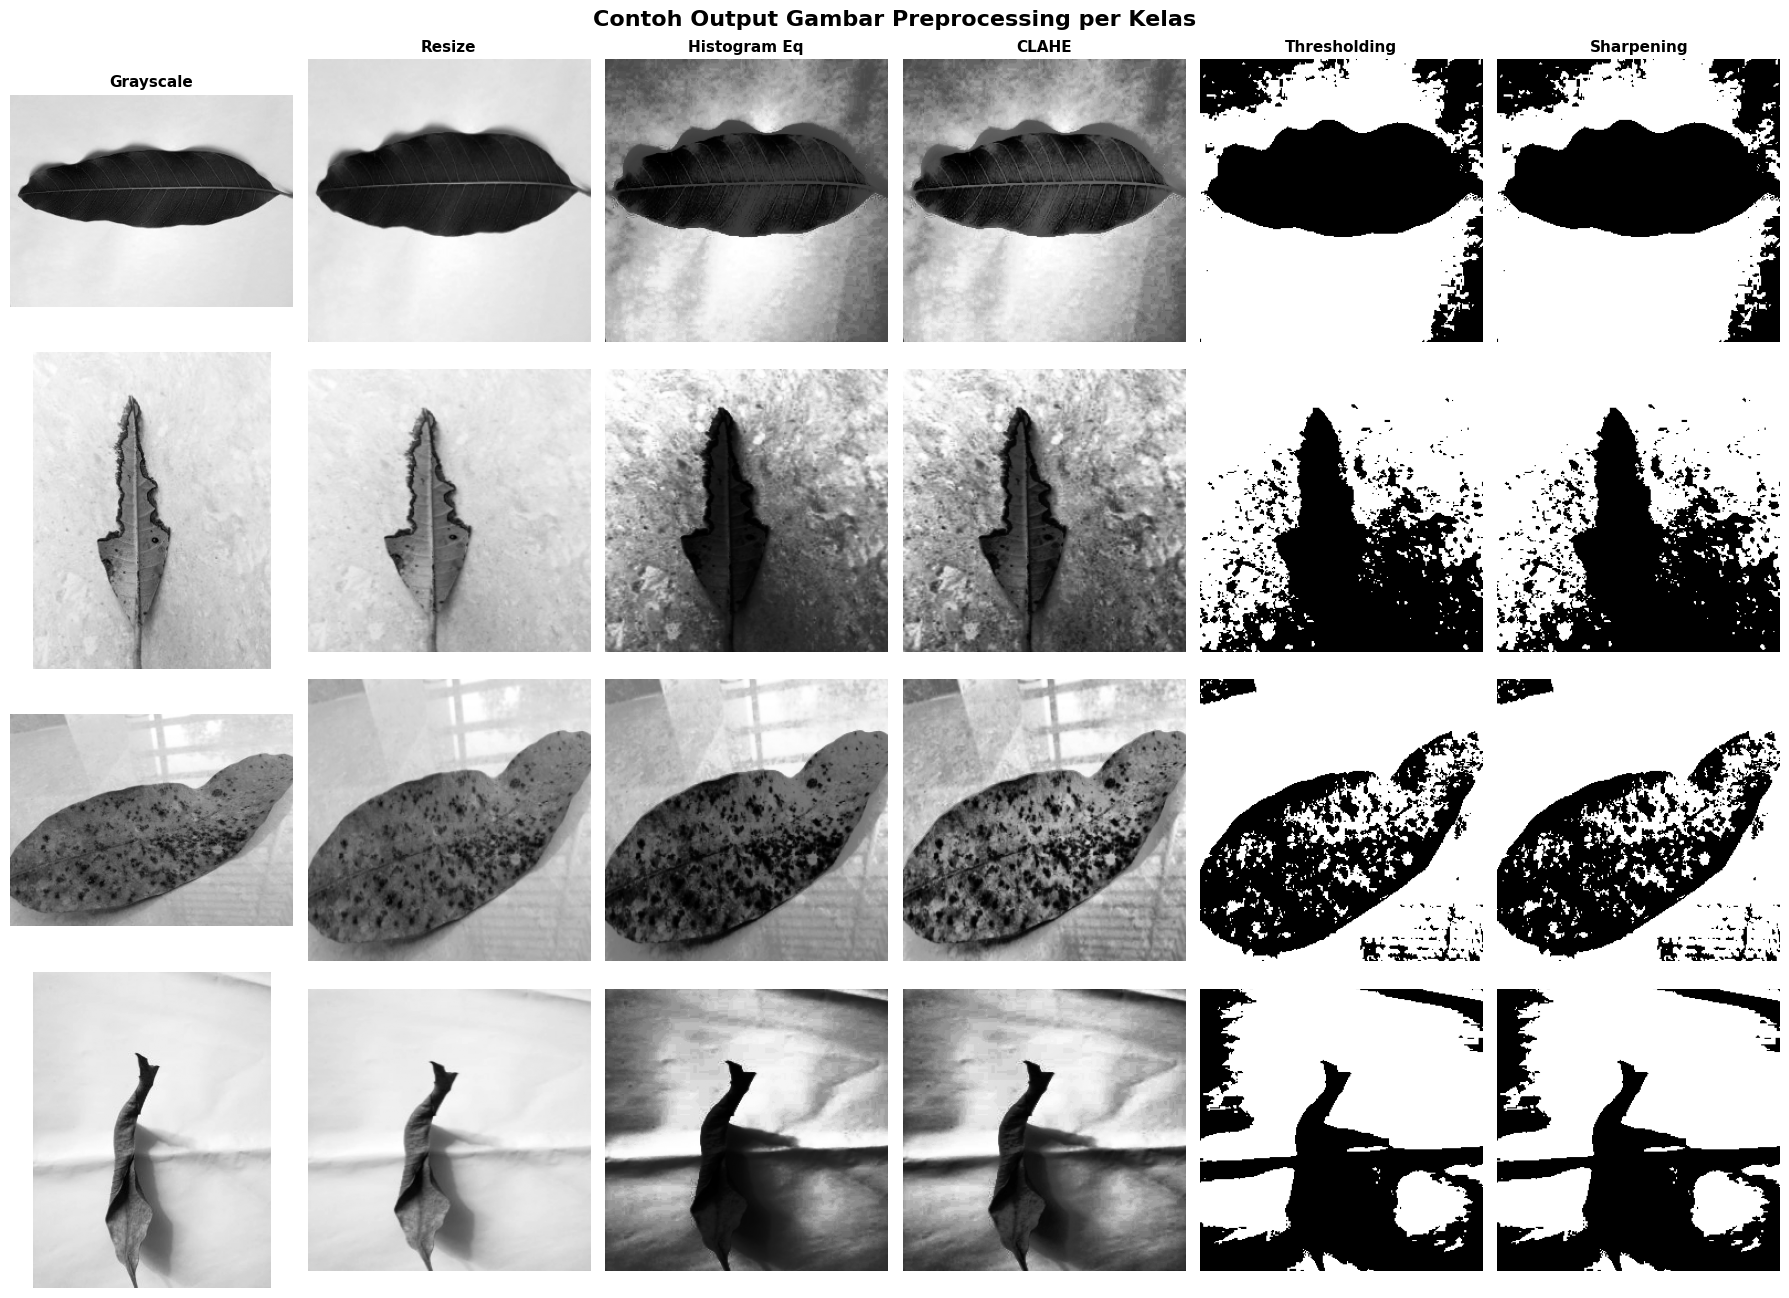

In [72]:
def get_preprocessing_steps_for_display(img):
    img_gray = img

    img_resize = cv.resize(img_gray, target_size, interpolation=cv.INTER_AREA)

    img_heq = cv.equalizeHist(img_resize)

    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_heq)

    _, img_threshold = cv.threshold(img_clahe, 127, 255, cv.THRESH_BINARY)

    img_sharpened = cv.filter2D(img_threshold, -1, kernelSharpening)
    img_sharpened = np.clip(img_sharpened, 0, 255).astype(np.uint8)

    return [img_gray, img_resize, img_heq, img_clahe, img_threshold, img_sharpened]


def show_preprocessing_samples(data, labels, target_classes):
    stage_titles = [
        'Grayscale',
        'Resize',
        'Histogram Eq',
        'CLAHE',
        'Thresholding',
        'Sharpening'
    ]

    sample_indices = []
    for class_name in target_classes:
        matches = np.where(labels == class_name)[0]
        if len(matches) > 0:
            sample_indices.append(matches[0])

    if len(sample_indices) == 0:
        print("Tidak ada data yang bisa divisualisasikan.")
        return

    fig, axes = plt.subplots(
        len(sample_indices),
        len(stage_titles),
        figsize=(18, 3.3 * len(sample_indices))
    )

    if len(sample_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(sample_indices):
        steps = get_preprocessing_steps_for_display(data[idx])

        for col, (img_step, title) in enumerate(zip(steps, stage_titles)):
            axes[row, col].imshow(img_step, cmap='gray')
            axes[row, col].axis('off')

            if row == 0:
                axes[row, col].set_title(title, fontsize=11, fontweight='bold')

            if col == 0:
                axes[row, col].set_ylabel(
                    labels[idx],
                    rotation=0,
                    labelpad=60,
                    fontsize=10,
                    fontweight='bold',
                    va='center'
                )

    plt.suptitle('Contoh Output Gambar Preprocessing per Kelas', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_preprocessing_samples(data, labels, target_classes)

In [73]:
print("\nMemulai proses Ekstraksi Fitur GLCM...")
print("="*70)

def calculate_glcm(image, angle_deg):
    if angle_deg == 0:
        angle = [0]
    elif angle_deg == 45:
        angle = [np.pi / 4]
    elif angle_deg == 90:
        angle = [np.pi / 2]
    elif angle_deg == 135:
        angle = [3 * np.pi / 4]

    glcm_matrix = graycomatrix(image, [1], angle, 256, symmetric=True, normed=True)
    return glcm_matrix

def extract_glcm_features(glcm_matrix):
    contrast = graycoprops(glcm_matrix, 'contrast')[0, 0]
    dissimilarity = graycoprops(glcm_matrix, 'dissimilarity')[0, 0]
    homogeneity = graycoprops(glcm_matrix, 'homogeneity')[0, 0]
    energy = graycoprops(glcm_matrix, 'energy')[0, 0]
    correlation = graycoprops(glcm_matrix, 'correlation')[0, 0]
    asm = graycoprops(glcm_matrix, 'ASM')[0, 0]
    entropy_val = entropy(glcm_matrix.ravel())

    return [contrast, dissimilarity, homogeneity, energy, correlation, asm, entropy_val]

angles = [0, 45, 90, 135]
feature_names = ['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Correlation', 'ASM', 'Entropy']

all_features = {}
for angle in angles:
    for fname in feature_names:
        all_features[f"{fname}_{angle}"] = []

print(f"Extracting GLCM features for {len(data_sharpened)} images...")
start_time = time.time()

for idx, img in enumerate(data_sharpened):
    if (idx + 1) % 100 == 0:
        print(f"  Processing: {idx + 1}/{len(data_sharpened)}")

    for angle in angles:
        glcm = calculate_glcm(img, angle)
        features = extract_glcm_features(glcm)

        for i, fname in enumerate(feature_names):
            all_features[f"{fname}_{angle}"].append(features[i])

elapsed_time = time.time() - start_time

hasilEkstrak = pd.DataFrame(all_features)
hasilEkstrak['Filename'] = file_name
hasilEkstrak['Label'] = labels

cols = ['Filename', 'Label'] + [col for col in hasilEkstrak.columns if col not in ['Filename', 'Label']]
hasilEkstrak = hasilEkstrak[cols]

print("="*70)
print(" Feature extraction complete!")
print(f"  Total features: {hasilEkstrak.shape[1] - 2}")
print(f"  Total samples: {hasilEkstrak.shape[0]}")
print(f"  Time elapsed: {elapsed_time:.2f} seconds")
print(f"\nDataframe shape: {hasilEkstrak.shape}")


Memulai proses Ekstraksi Fitur GLCM...
Extracting GLCM features for 2000 images...
  Processing: 100/2000
  Processing: 200/2000
  Processing: 300/2000
  Processing: 400/2000
  Processing: 500/2000
  Processing: 600/2000
  Processing: 700/2000
  Processing: 800/2000
  Processing: 900/2000
  Processing: 1000/2000
  Processing: 1100/2000
  Processing: 1200/2000
  Processing: 1300/2000
  Processing: 1400/2000
  Processing: 1500/2000
  Processing: 1600/2000
  Processing: 1700/2000
  Processing: 1800/2000
  Processing: 1900/2000
  Processing: 2000/2000
 Feature extraction complete!
  Total features: 28
  Total samples: 2000
  Time elapsed: 41.85 seconds

Dataframe shape: (2000, 30)


Setelah preprocessing selesai, dilakukan ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix atau GLCM. GLCM digunakan untuk menghitung hubungan antar piksel berdasarkan tingkat keabuan pada jarak dan sudut tertentu. Karena penyakit pada daun mangga umumnya memengaruhi pola permukaan dan tekstur daun, maka GLCM sesuai digunakan untuk mengambil informasi tekstur dari citra.

Pada percobaan ini, ekstraksi fitur dilakukan pada empat sudut, yaitu 0°, 45°, 90°, dan 135°. Penggunaan beberapa sudut bertujuan agar pola tekstur dari berbagai arah dapat tertangkap. Hal ini penting karena arah bercak, tepi, atau pola kerusakan pada daun tidak selalu sama pada setiap gambar.

Fitur yang diambil dari GLCM meliputi Contrast, Dissimilarity, Homogeneity, Energy, Correlation, ASM, dan Entropy. Contrast digunakan untuk melihat perbedaan intensitas antar piksel. Dissimilarity menunjukkan tingkat ketidaksamaan antar piksel. Homogeneity menunjukkan keseragaman tekstur. Energy dan ASM menunjukkan keteraturan pola tekstur. Correlation menunjukkan hubungan linear antar piksel. Entropy menunjukkan tingkat kompleksitas atau ketidakteraturan tekstur.

Hasil ekstraksi fitur kemudian disimpan dalam dataframe, dengan setiap baris mewakili satu citra dan setiap kolom mewakili fitur GLCM dari sudut tertentu. Dataset fitur inilah yang digunakan sebagai input untuk proses klasifikasi.

In [74]:
csv_filename = "hasil_ekstraksi_percobaan_3.csv"
csv_path = os.path.abspath(csv_filename)

hasilEkstrak.to_csv(csv_path, index=False)
display(hasilEkstrak)
print(" Hasil ekstraksi fitur berhasil disimpan!")
print(f"Nama file : {csv_filename}")
print(f"Lokasi    : {csv_path}")
print(f"Shape CSV : {hasilEkstrak.shape}")

,Filename,Label,Contrast_0,Dissimilarity_0,Homogeneity_0,Energy_0,Correlation_0,ASM_0,Entropy_0,Contrast_45,...,Correlation_90,ASM_90,Entropy_90,Contrast_135,Dissimilarity_135,Homogeneity_135,Energy_135,Correlation_135,ASM_135,Entropy_135
0,20211231_154907 (Custom).jpg,Healthy,1498.125000,5.875000,0.976961,0.697049,0.953136,0.485877,0.794181,2374.0,...,0.943052,0.481064,0.812329,2218.0,8.698039,0.965891,0.689530,0.930615,0.475451,0.833177
1,20211231_161331 (Custom).jpg,Healthy,866.601562,3.398438,0.986673,0.706830,0.972648,0.499609,0.750943,1858.0,...,0.951113,0.489816,0.792213,1747.0,6.850980,0.973134,0.697738,0.944834,0.486838,0.803420
2,20211231_125736 (Custom).jpg,Healthy,725.156250,2.843750,0.988848,0.708022,0.977133,0.501295,0.741863,907.0,...,0.983969,0.504919,0.726010,877.0,3.439216,0.986513,0.706490,0.972338,0.499128,0.751961
3,20211231_160853 (Custom).jpg,Healthy,792.890625,3.109375,0.987807,0.705479,0.975128,0.497701,0.749102,1532.0,...,0.965192,0.492968,0.769588,1130.0,4.431373,0.982622,0.701696,0.964574,0.492377,0.771146
4,20211231_162159 (Custom).jpg,Healthy,1299.902344,5.097656,0.980009,0.701430,0.959069,0.492004,0.779271,1079.0,...,0.968561,0.496156,0.761045,1781.0,6.984314,0.972611,0.696187,0.943953,0.484676,0.807014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,20211129_162952 (Custom).jpg,Die Back,580.722656,2.277344,0.991069,0.706830,0.981831,0.499608,0.735615,925.0,...,0.977349,0.497323,0.745855,873.0,3.423529,0.986575,0.703686,0.972689,0.495174,0.755796
1996,20211129_161817 (Custom).jpg,Die Back,520.957031,2.042969,0.991988,0.708355,0.983659,0.501767,0.729973,849.0,...,0.979654,0.499978,0.739038,722.0,2.831373,0.988897,0.706265,0.977350,0.498810,0.744226
1997,20211129_164415 (Custom).jpg,Die Back,567.773438,2.226562,0.991269,0.709250,0.982119,0.503035,0.731394,572.0,...,0.984747,0.504508,0.725010,827.0,3.243137,0.987282,0.706536,0.973952,0.499193,0.749346
1998,20211129_163113 (Custom).jpg,Die Back,681.328125,2.671875,0.989522,0.704422,0.978765,0.496211,0.744670,876.0,...,0.982281,0.497690,0.736877,815.0,3.196078,0.987467,0.702828,0.974611,0.493967,0.754053


 Hasil ekstraksi fitur berhasil disimpan!
Nama file : hasil_ekstraksi_percobaan_3.csv
Lokasi    : /content/pcd26/hasil_ekstraksi_percobaan_3.csv
Shape CSV : (2000, 30)


Setelah proses ekstraksi fitur GLCM selesai, diperoleh sebuah dataframe yang berisi seluruh fitur tekstur dari setiap citra daun mangga. Setiap baris pada dataframe merepresentasikan satu citra, sedangkan setiap kolom merepresentasikan fitur hasil ekstraksi GLCM dari berbagai sudut pengamatan.

Pada tahap ini dilakukan pemisahan antara fitur (X) dan label (y). Kolom Label digunakan sebagai target klasifikasi karena berisi informasi kelas dari setiap citra, sedangkan kolom Filename tidak digunakan dalam proses pembelajaran model karena hanya berisi nama file gambar dan tidak memiliki informasi yang relevan terhadap karakteristik tekstur daun.

Seluruh kolom fitur hasil ekstraksi GLCM, seperti Contrast, Dissimilarity, Homogeneity, Energy, Correlation, ASM, dan Entropy pada sudut 0°, 45°, 90°, dan 135°, digunakan sebagai variabel masukan (X). Sementara itu, kolom Label digunakan sebagai variabel keluaran (y). Hasil pemisahan ini menghasilkan dataset fitur yang siap digunakan pada tahap seleksi fitur, pembagian data, normalisasi, dan proses klasifikasi.

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*70)
print("Data Splitting & Normalization")
print("="*70)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\n Normalization (StandardScaler) applied")
print(f"  Train mean: {X_train.mean():.4f}")
print(f"  Train std: {X_train.std():.4f}")


Data Splitting & Normalization
Training set: 1600 samples
Testing set: 400 samples
Features: 28

 Normalization (StandardScaler) applied
  Train mean: 0.0000
  Train std: 1.0000


Setelah fitur GLCM berhasil diperoleh, data kemudian dibagi menjadi dua bagian, yaitu data training dan data testing. Data training digunakan untuk melatih model agar dapat mengenali pola pada setiap kelas daun mangga, sedangkan data testing digunakan untuk mengukur kemampuan model dalam mengklasifikasikan data yang belum pernah dilihat sebelumnya.

Pada penelitian ini digunakan pembagian data sebesar 80% untuk training dan 20% untuk testing. Selain itu, digunakan parameter stratify agar proporsi setiap kelas tetap terjaga pada kedua kelompok data. Dengan cara ini, setiap kelas memiliki jumlah representasi yang relatif seimbang sehingga proses pelatihan dan pengujian menjadi lebih adil.

Sebelum data digunakan untuk proses klasifikasi, dilakukan normalisasi menggunakan metode StandardScaler. Normalisasi dilakukan karena nilai fitur hasil ekstraksi GLCM memiliki rentang yang berbeda-beda. Jika perbedaan skala ini dibiarkan, beberapa fitur dapat menjadi lebih dominan dibandingkan fitur lainnya dan memengaruhi kinerja model.

Melalui proses normalisasi, seluruh fitur diubah ke skala yang lebih seragam sehingga setiap fitur memiliki kontribusi yang lebih seimbang dalam proses pembelajaran model. Dengan demikian, model klasifikasi dapat bekerja lebih optimal dalam mengenali pola tekstur dari setiap kelas daun mangga.

In [76]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(
        y_true, y_pred,
        target_names=np.unique(y_true),
        digits=4
    ))

ada tahap ini dilakukan persiapan model klasifikasi dan fungsi evaluasi yang akan digunakan pada proses pengujian. Model yang digunakan dalam penelitian ini terdiri dari Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN). Ketiga model tersebut dipilih karena memiliki pendekatan yang berbeda dalam melakukan klasifikasi, sehingga dapat digunakan untuk membandingkan performa klasifikasi berdasarkan fitur tekstur yang diperoleh dari GLCM.

Selain itu, dibuat fungsi evaluasi yang bertujuan untuk menampilkan hasil klasifikasi dalam bentuk classification report. Fungsi ini digunakan untuk menghitung beberapa metrik evaluasi, seperti accuracy, precision, recall, dan F1-score. Melalui metrik tersebut dapat diketahui seberapa baik model dalam mengenali setiap kelas daun mangga.

In [77]:
print("\n" + "="*70)
print("Model 1: Random Forest Classifier")
print("="*70)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average='weighted', zero_division=0)

print(f"\nAccuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print("\nClassification Report:")
generateClassificationReport(y_test, rf_pred)


Model 1: Random Forest Classifier

Accuracy: 0.6950
Precision: 0.6970
Recall: 0.6950
F1-Score: 0.6925

Classification Report:
                  precision    recall  f1-score   support

Bacterial Canker     0.8108    0.9000    0.8531       100
        Die Back     0.6700    0.6700    0.6700       100
         Healthy     0.5766    0.6400    0.6066       100
     Sooty Mould     0.7308    0.5700    0.6404       100

        accuracy                         0.6950       400
       macro avg     0.6970    0.6950    0.6925       400
    weighted avg     0.6970    0.6950    0.6925       400



Pada tahap ini dilakukan proses training menggunakan algoritma Random Forest dengan data training yang telah melalui tahap normalisasi sebelumnya. Random Forest merupakan metode klasifikasi berbasis kumpulan decision tree yang bekerja dengan menggabungkan hasil prediksi dari banyak pohon keputusan untuk menghasilkan prediksi akhir yang lebih stabil dan akurat.

erdasarkan hasil pengujian, model Random Forest memperoleh accuracy sebesar 69,50%, precision sebesar 69,70%, recall sebesar 69,50%, dan F1-score sebesar 69,25%. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data dengan cukup baik, meskipun masih terdapat kesalahan klasifikasi pada beberapa kelas.

Kelas Bacterial Canker memiliki performa terbaik dengan F1-score sebesar 85,31% dan recall sebesar 90,00%, yang menunjukkan bahwa sebagian besar citra pada kelas ini berhasil dikenali dengan benar. Sebaliknya, kelas Healthy memiliki performa yang lebih rendah dengan F1-score sebesar 60,66%, menunjukkan bahwa model masih mengalami kesulitan dalam membedakan daun sehat dengan beberapa kelas penyakit yang memiliki karakteristik tekstur serupa.

In [78]:
print("\n" + "="*70)
print("Model 2: Support Vector Machine (SVM)")
print("="*70)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted', zero_division=0)
svm_recall = recall_score(y_test, svm_pred, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, average='weighted', zero_division=0)

print(f"\nAccuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print("\nClassification Report:")
generateClassificationReport(y_test, svm_pred)


Model 2: Support Vector Machine (SVM)

Accuracy: 0.6700
Precision: 0.7032
Recall: 0.6700
F1-Score: 0.6568

Classification Report:
                  precision    recall  f1-score   support

Bacterial Canker     0.7519    0.9700    0.8472       100
        Die Back     0.5950    0.7200    0.6516       100
         Healthy     0.5566    0.5900    0.5728       100
     Sooty Mould     0.9091    0.4000    0.5556       100

        accuracy                         0.6700       400
       macro avg     0.7032    0.6700    0.6568       400
    weighted avg     0.7032    0.6700    0.6568       400



Pada tahap ini dilakukan proses training menggunakan algoritma Support Vector Machine (SVM). Algoritma ini bekerja dengan mencari batas pemisah terbaik (hyperplane) yang dapat membedakan data dari kelas yang berbeda. Pada penelitian ini digunakan kernel RBF (Radial Basis Function) karena mampu menangani pola data yang tidak selalu dapat dipisahkan secara linear.

Model SVM memperoleh accuracy sebesar 67,00%, precision sebesar 70,32%, recall sebesar 67,00%, dan F1-score sebesar 65,68%. Hasil ini menunjukkan bahwa performa SVM sedikit lebih rendah dibandingkan Random Forest.

Kelas Bacterial Canker kembali menjadi kelas dengan performa terbaik, ditunjukkan oleh recall sebesar 97,00% dan F1-score sebesar 84,72%. Hal ini menunjukkan bahwa pola tekstur pada kelas tersebut cukup mudah dipisahkan oleh SVM. Namun, pada kelas Sooty Mould, recall hanya mencapai 40,00%, yang berarti sebagian besar citra pada kelas tersebut masih sering diklasifikasikan ke kelas lain.

Perbedaan nilai recall yang cukup besar antar kelas menunjukkan bahwa SVM belum mampu membentuk batas pemisah yang optimal untuk seluruh kelas. Meskipun demikian, nilai precision yang cukup tinggi menunjukkan bahwa prediksi yang diberikan model cenderung tepat ketika model yakin terhadap hasil klasifikasinya.

In [79]:
print("\n" + "="*70)
print("Model 3: K-Nearest Neighbor (KNN)")
print("="*70)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted', zero_division=0)
knn_recall = recall_score(y_test, knn_pred, average='weighted', zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, average='weighted', zero_division=0)

print(f"\nAccuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1:.4f}")
print("\nClassification Report:")
generateClassificationReport(y_test, knn_pred)


Model 3: K-Nearest Neighbor (KNN)

Accuracy: 0.6775
Precision: 0.6828
Recall: 0.6775
F1-Score: 0.6691

Classification Report:
                  precision    recall  f1-score   support

Bacterial Canker     0.7778    0.9100    0.8387       100
        Die Back     0.6063    0.7700    0.6784       100
         Healthy     0.5934    0.5400    0.5654       100
     Sooty Mould     0.7538    0.4900    0.5939       100

        accuracy                         0.6775       400
       macro avg     0.6828    0.6775    0.6691       400
    weighted avg     0.6828    0.6775    0.6691       400



ada tahap ini dilakukan proses training menggunakan algoritma K-Nearest Neighbor (KNN). Algoritma KNN melakukan klasifikasi berdasarkan kedekatan jarak antar data. Suatu data akan dimasukkan ke kelas yang paling banyak muncul dari sejumlah tetangga terdekatnya. Pada penelitian ini digunakan nilai k = 5, sehingga proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari setiap data.

Model KNN memperoleh accuracy sebesar 67,75%, precision sebesar 68,28%, recall sebesar 67,75%, dan F1-score sebesar 66,91%. Hasil ini sedikit lebih baik dibandingkan SVM, namun masih berada di bawah Random Forest.

Kelas Bacterial Canker kembali menunjukkan performa terbaik dengan F1-score sebesar 83,87% dan recall sebesar 91,00%. Sebaliknya, kelas Sooty Mould memiliki recall sebesar 49,00%, yang menunjukkan bahwa hampir setengah data pada kelas tersebut masih salah diklasifikasikan.

Hasil ini menunjukkan bahwa data dari kelas yang sama memiliki kemiripan fitur yang cukup baik sehingga dapat dikenali menggunakan konsep tetangga terdekat. Namun, beberapa kelas masih memiliki karakteristik tekstur yang saling berdekatan sehingga menyebabkan kesalahan klasifikasi.


Confusion Matrices


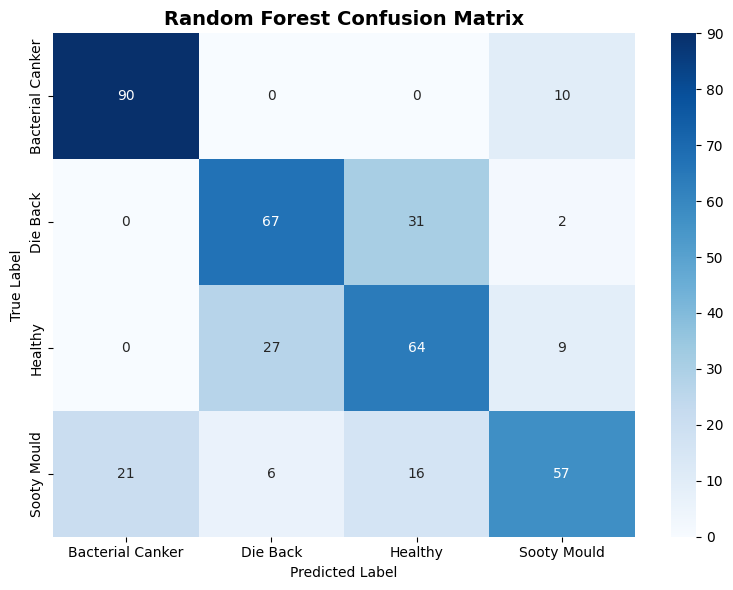

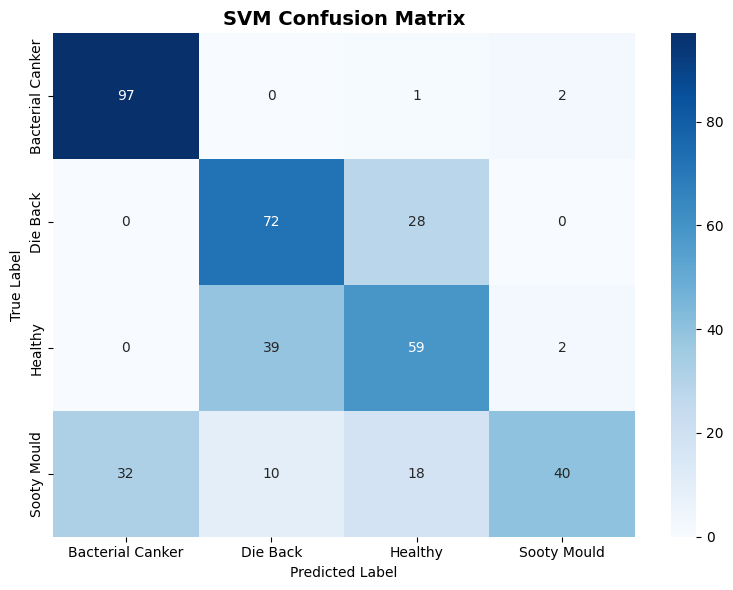

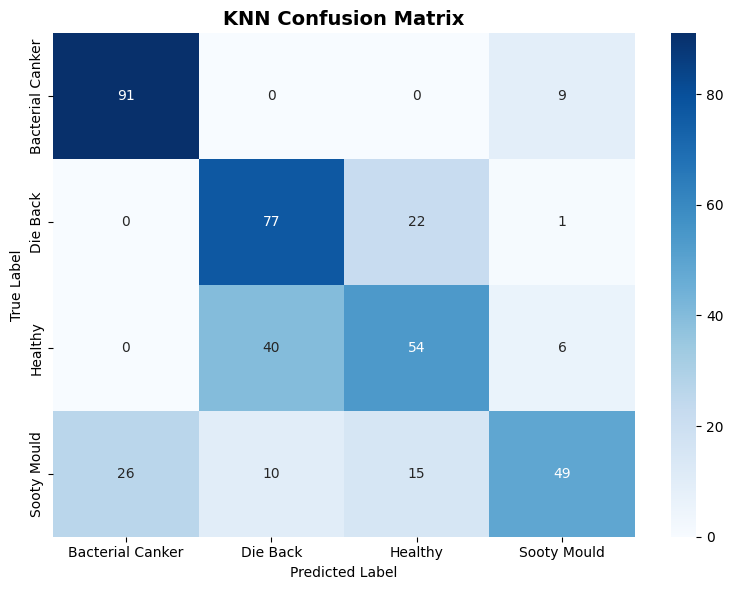

In [80]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return cm

print("\n" + "="*70)
print("Confusion Matrices")
print("="*70)

rf_cm = plot_confusion_matrix(y_test, rf_pred, "Random Forest Confusion Matrix")
svm_cm = plot_confusion_matrix(y_test, svm_pred, "SVM Confusion Matrix")
knn_cm = plot_confusion_matrix(y_test, knn_pred, "KNN Confusion Matrix")

Berdasarkan confusion matrix, ketiga model mampu mengenali kelas Bacterial Canker dengan baik, terlihat dari banyaknya prediksi yang berada pada diagonal utama. Sebaliknya, kesalahan klasifikasi paling sering terjadi antara kelas Die Back dan Healthy, yang menunjukkan adanya kemiripan karakteristik tekstur pada kedua kelas tersebut.
Model Random Forest menghasilkan distribusi prediksi yang paling baik dengan accuracy sebesar 69,50%, diikuti oleh KNN sebesar 67,75%, dan SVM sebesar 67,00%. Secara keseluruhan, hasil confusion matrix menunjukkan bahwa fitur GLCM mampu membedakan sebagian besar kelas daun mangga, meskipun masih terdapat beberapa kelas yang sering tertukar karena memiliki tekstur yang mirip.